# OncoPlus: Breast Cancer Prediction using Machine Learning

This project predicts whether a breast tumor is Benign or Malignant using machine learning.

Dataset:
Breast Cancer Wisconsin Diagnostic Dataset

Workflow:
EDA → Feature Selection (RFECV) → Outlier Removal (LOF) → Model Training → Evaluation → Deployment

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Importing the Dependencies**

In [2]:
import numpy
import pandas
import sklearn
import joblib

print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)


numpy: 2.0.2
pandas: 2.2.2
sklearn: 1.6.1
joblib: 1.5.3


In [17]:
# ==========================================================
# Import Required Libraries
# ==========================================================
# These libraries are used for data processing, visualization,
# feature selection, model training, evaluation and deployment.

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import joblib
import json
import os

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.neighbors import LocalOutlierFactor

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

**Loading Kaggle Dataset : Breast Cancer Wisconsin dataset (569 samples, 32 features)**

In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "data.csv"   # file inside the dataset

# Load the latest version
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/breast-cancer-wisconsin-data",
    file_path,
)

print("First 5 records:")
print(df.head())


Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
First 5 records:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280    

**EDA (Exploratory Data Analysis)**

In [5]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


Class Distribution

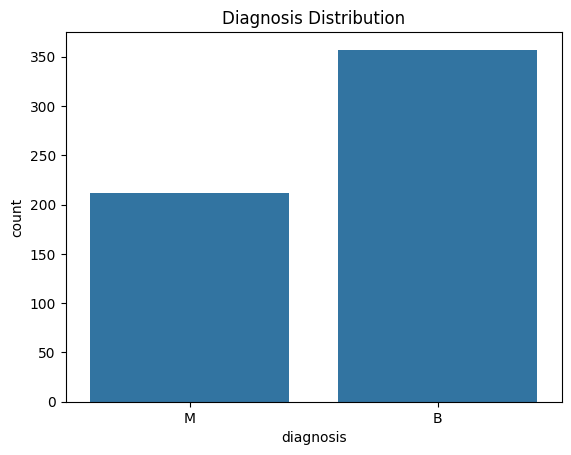

In [6]:
sns.countplot(x='diagnosis', data=df)
plt.title("Diagnosis Distribution")
plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

**Data Cleaning**

In [8]:
# Dropping columns
df.drop(['Unnamed: 32','id'], axis = 1 , inplace=True)
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

**Label Encoding**

In [9]:
df['diagnosis'] = df['diagnosis'].map({
    'M': 1,
    'B': 0
})

**Split Features and Target**

In [10]:
# Separate input features and target variable for model training
X = df.drop("diagnosis", axis=1)   # All predictor features
y = df["diagnosis"]                # Target label (0 = Benign, 1 = Malignant)

**RFECV Feature Selection (Recursive Feature Elimination through Cross Validation)**

In [11]:
estimator = LogisticRegression(max_iter=2000)

rfecv = RFECV(
    estimator,
    step=1,
    cv=StratifiedKFold(5),
    scoring="accuracy",
    n_jobs=-1
)
rfecv.fit(X, y)


RFECV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
      estimator=LogisticRegression(max_iter=2000), n_jobs=-1,
      scoring='accuracy')

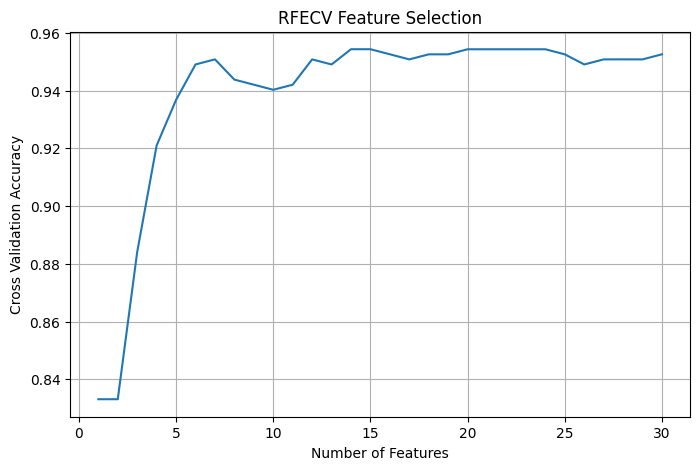

In [14]:
# Visualize how model accuracy changes as RFECV recursively selects features
# This helps identify the optimal number of features that maximizes
# cross-validation accuracy while reducing unnecessary variables.

# The peak of the curve indicates the optimal number of features that provides
# the highest predictive performance while avoiding unnecessary complexity.

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
    rfecv.cv_results_["mean_test_score"]
)

plt.xlabel("Number of Features")
plt.ylabel("Cross Validation Accuracy")
plt.title("RFECV Feature Selection")
plt.grid(True)

plt.show()

In [12]:
selected_features = X.columns[rfecv.support_]

print("Optimal number of features:", rfecv.n_features_)
print("\nSelected Features:")
for f in selected_features:
    print(f)


Optimal number of features: 14

Selected Features:
radius_mean
compactness_mean
concavity_mean
concave points_mean
symmetry_mean
texture_se
perimeter_se
radius_worst
texture_worst
smoothness_worst
compactness_worst
concavity_worst
concave points_worst
symmetry_worst


In [15]:
# Build Feature Matrix using RFECV Selected Features

# Only the most informative features are retained
# for model training.

X = df[selected_features].copy()

y = df["diagnosis"].copy().values

**Detect Outliers using :- Local Outlier Factor (LOF)**

In [24]:
# LOF identifies samples whose local density
# significantly differs from neighboring observations.

lof = LocalOutlierFactor()

y_lof = lof.fit_predict(X)

scores = lof.negative_outlier_factor_

outlier_score = pd.DataFrame({
    "score": scores
})

threshold = -2.5

outlier_idx = outlier_score[
    outlier_score["score"] < threshold
].index.tolist()

print("Outliers detected:", len(outlier_idx))

Outliers detected: 1


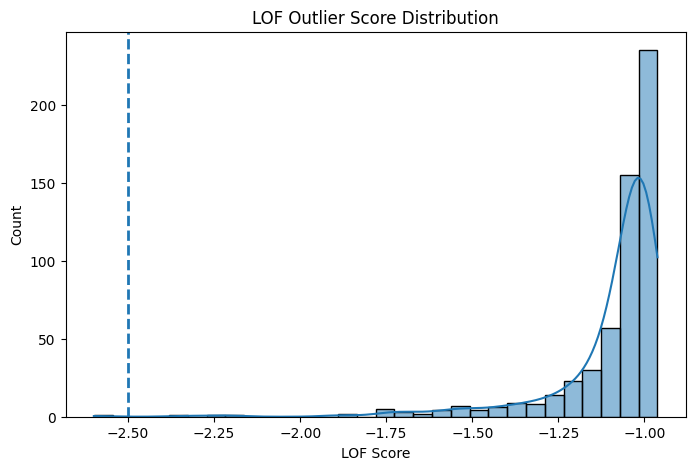

In [25]:
# LOF Score Distribution


plt.figure(figsize=(8,5))

sns.histplot(
    outlier_score["score"],
    bins=30,
    kde=True
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2
)

plt.title("LOF Outlier Score Distribution")

plt.xlabel("LOF Score")

plt.show()

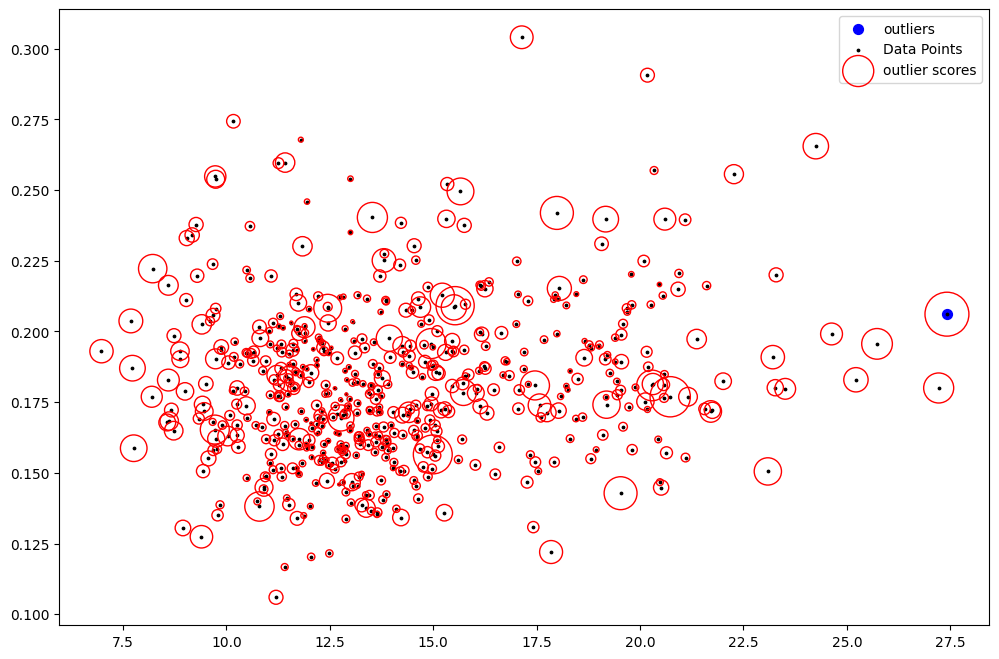

In [26]:
plt.figure(figsize=(12,8.))
plt.scatter(X.iloc[outlier_idx,0],X.iloc[outlier_idx,4],color="blue",s=50,label="outliers")
plt.scatter(X.iloc[:,0],X.iloc[:,4],color="k",s=3,label="Data Points")

radius=(scores.max()- scores)/(scores.max()-scores.min())
outlier_score["radius"]=radius
plt.scatter(X.iloc[:,0],X.iloc[:,4],s=1000*radius,edgecolors="r",facecolors="none",label="outlier scores")
plt.legend();


In [27]:
# Remove Detected Outliers

if len(outlier_idx) > 0:
    X = X.drop(index=outlier_idx).reset_index(drop=True)
    y = np.delete(y, outlier_idx)

else:
    X = X.reset_index(drop=True)

print("Shape after outlier removal:", X.shape)

Shape after outlier removal: (567, 14)


**Train-Test Split**

In [28]:
# Split Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

**Feature Scaling**

In [29]:
# Standardize Features
# Scaling ensures all features contribute equally.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Model Training & Evaluation**

In [30]:
# DEFINE ALL MODELS

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric="logloss", use_label_encoder=False)
}


results = []
conf_matrices = {}

In [31]:
# TRAIN + EVALUATE ALL MODELS

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # ROC-AUC handling
    try:
        prob = model.predict_proba(X_test_scaled)[:, 1]
    except:
        try:
            df_score = model.decision_function(X_test_scaled)
            prob = 1 / (1 + np.exp(-df_score))
        except:
            prob = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    roc = roc_auc_score(y_test, prob) if prob is not None else np.nan

    results.append([name, acc, prec, rec, f1, roc])
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

In [32]:
# CREATE RESULTS TABLE

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
).set_index("Model")

results_df = results_df.sort_values("Accuracy", ascending=False)

print("\n\n=== MODEL PERFORMANCE TABLE ===")
print(results_df)



=== MODEL PERFORMANCE TABLE ===
                     Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                 
Logistic Regression  0.982456   1.000000  0.952381  0.975610  0.991182
XGBoost              0.976608   1.000000  0.936508  0.967213  0.986772
Random Forest        0.970760   1.000000  0.920635  0.958678  0.991623
SVM                  0.970760   0.983333  0.936508  0.959350  0.993239
KNN                  0.953216   0.982456  0.888889  0.933333  0.979277
Decision Tree        0.953216   0.966102  0.904762  0.934426  0.943122


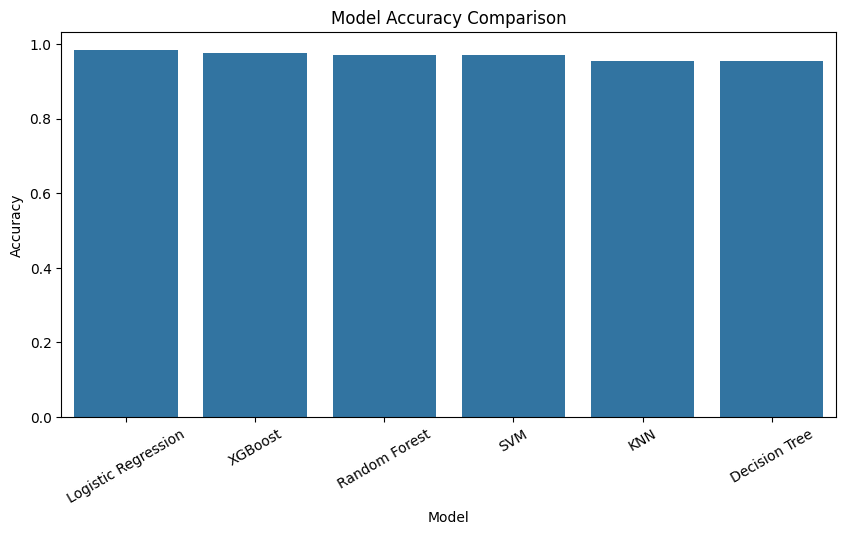

In [33]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=results_df.index,
    y=results_df["Accuracy"]
)

plt.xticks(rotation=30)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

**Selecting the Best Model**

In [34]:
# CHOOSE BEST MODEL

best_model_name = results_df.index[0]
best_model = models[best_model_name]

print("\nBest model:", best_model_name)
print("Confusion matrix:")
print(conf_matrices[best_model_name])


Best model: Logistic Regression
Confusion matrix:
[[108   0]
 [  3  60]]


Confusion Matrix Heatmap

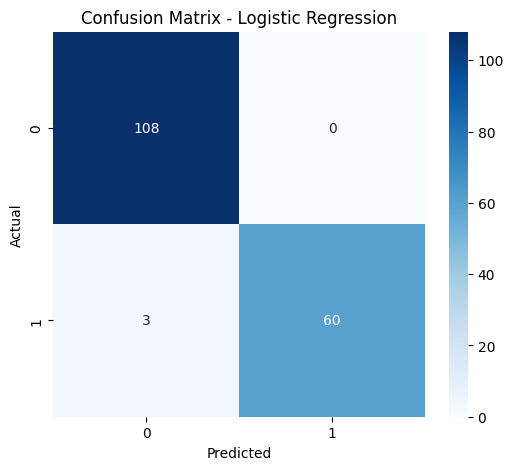

In [35]:
plt.figure(figsize=(6,5))

sns.heatmap(
    conf_matrices[best_model_name],
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix - {best_model_name}'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Logistic Regression Feature Importance

In Logistic Regression:

Positive coefficient → higher feature value increases the probability of class 1 (Malignant).
Negative coefficient → higher feature value decreases the probability of class 1 (Malignant), or equivalently increases the probability of class 0 (Benign).

RFECV evaluates the contribution of features based on overall cross-validation accuracy, not on whether coefficients are positive or negative. Some features have negative coefficients but still improve predictive performance. Since RFECV retained them in the optimal 14-feature subset, removing them would likely reduce model performance.

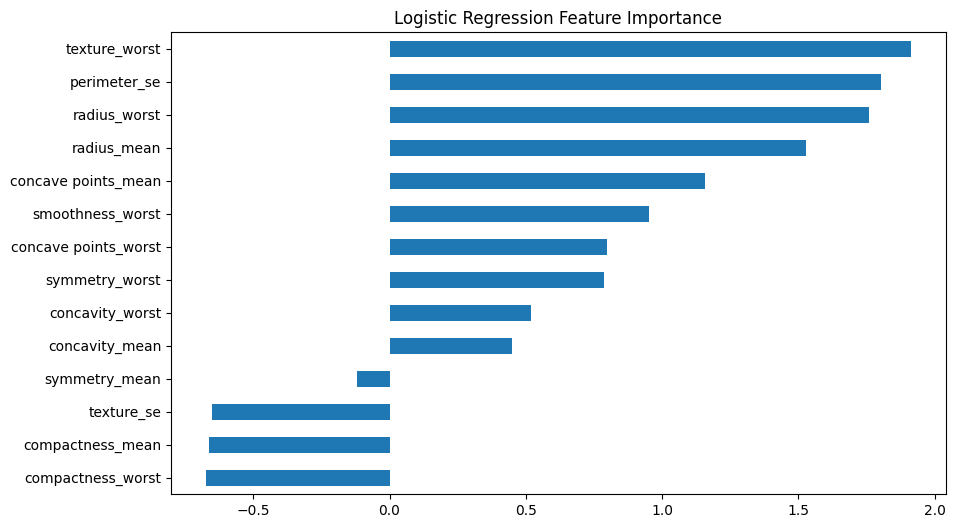

In [36]:
if best_model_name == "Logistic Regression":

    importance = pd.Series(
        best_model.coef_[0],
        index=selected_features
    )

    importance = importance.sort_values()

    plt.figure(figsize=(10,6))

    importance.plot(kind="barh")

    plt.title(
        "Logistic Regression Feature Importance"
    )

    plt.show()

**Saving the Deployment Artifacts**

In [37]:
# SAVE ARTIFACTS FOR PRODUCTION

os.makedirs("assets", exist_ok=True)

joblib.dump(best_model, "best_model_LR.pkl")
joblib.dump(scaler, "scaler.pkl")

# --- FIX: convert to list before saving ---
selected_features = list(selected_features)

with open("assets/features.json", "w") as f:
    json.dump(selected_features, f, indent=2)


print("\nSaved:")
print("- best_model_LR.pkl")
print("- scaler.pkl")
print("- assets/features.json")


# FINAL CHECK
print("\nVerification:")
print("features.json:", len(selected_features))
print("scaler.n_features_in_:", scaler.n_features_in_)
print("model input dimension:", best_model.coef_.shape[1] if best_model_name=="Logistic Regression" else "Not LR")


Saved:
- best_model_LR.pkl
- scaler.pkl
- assets/features.json

Verification:
features.json: 14
scaler.n_features_in_: 14
model input dimension: 14
